# INCOME CLASSIFICATION USING LOGISTIC REGRESSION

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>In this project, we will be using a dataset containing census information from the 1994 Census database to create a logistic regression model that predicts whether or not a person makes more than $50,000.</li>
    <ul>
</div>

<div style="background-color: #e6f7ff; padding: 10px;">
<b>EXECUTIVE SUMMARY</b><br>
    <ul>
        <li><b>Key Findings:</b> Education has the most effect on income. A person with Prof-school level of education earns the highest income, while 7th-8th grade level of education earns the lowest income.</li>
        <li>AUC score is 0.8, close to 1. The model has excellent ability to distinguish between the two classes. The score proves model has strong performance and good separability.</li>
        <li>ROC curve of the model stays above baseline, showing high true positive rate given any threshold. This proves model is good at distinguishing between classes.</li>
    </ul>
</div>

## 1. DATA DESCRIPTION

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>The original dataset was obtained from UCI Machine Learning Repository.</li>
    </ul>
</div>

<div style="background-color: #fff8e1; padding: 10px;">
    <table style="background-color: #f0fff0; border-collapse: collapse;">
        <tr>
            <th>Feature</th>
            <th>Description</th>
        </tr>
        <tr>
            <td>age</td>
            <td>continuous</td>
        </tr>
        <tr>
            <td>workclass</td>
            <td>
                <ul>
                    <li>Private</li>
                    <li>Self-emp-not-inc</li>
                    <li>Federal-gov</li>
                    <li>Local-gov</li>
                    <li>State-gov</li>
                    <li>Without-pay</li>
                    <li>Never-worked</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td>education</td>
            <td>
                <ul>
                    <li>Bachelors</li>
                    <li>Some-college</li>
                    <li>11th</li>
                    <li>HS-grad</li>
                    <li>Prof-school</li>
                    <li>Assoc-acdm</li>
                    <li>Assoc-voc</li>
                    <li>9th</li>
                    <li>7th-8th</li>
                    <li>12th</li>
                    <li>Masters</li>
                    <li>1st-4th</li>
                    <li>10th</li>
                    <li>Doctorate</li>
                    <li>5th-6th</li>
                    <li>Preschool</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td>race</td>
            <td>
                <ul>
                    <li>White</li>
                    <li>Asian-Pac-Islander</li>
                    <li>Amer-Indian-Eskimo</li>
                    <li>Other</li>
                    <li>Black</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td>sex</td>
            <td>
                <ul>
                    <li>Female</li>
                    <li>Male</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td>capital-gain</td>
            <td>continuous</td>
        </tr>
        <tr>
            <td>capital-loss</td>
            <td>continuous</td>
        </tr>
        <tr>
            <td>hours-per-week</td>
            <td>continuous</td>
        </tr>
        <tr>
            <td>native country</td>
            <td>discrete</td>
        </tr>
        <tr>
            <td>income</td>
            <td>
                <ul>
                    <li>discrete</li>
                    <li>>50k</li>
                    <li><=50k</li>
            </td>
        </tr>
    </table>
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [3]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv('adult.data', header=None, names=col_names)

In [4]:
# Clean columns by stripping extra whitespace for columns of type 'object'
for c in df.select_dtypes(include=['object', 'str']).columns:
    df[c] = df[c].str.strip()
df.head()

,age,workclass,fnlwgt,education,education-num,marital_status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Check for class imbalance
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [7]:
# Check for repeated samples
df['income'].nunique() == df['income'].value_counts()

income
<=50K    False
>50K     False
Name: count, dtype: bool

In [8]:
# Create feature dataframe X with feature columns and dummy variables for categorical features.
feature_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'sex', 'race', 'education']

X = pd.get_dummies(df[feature_cols], drop_first=True)

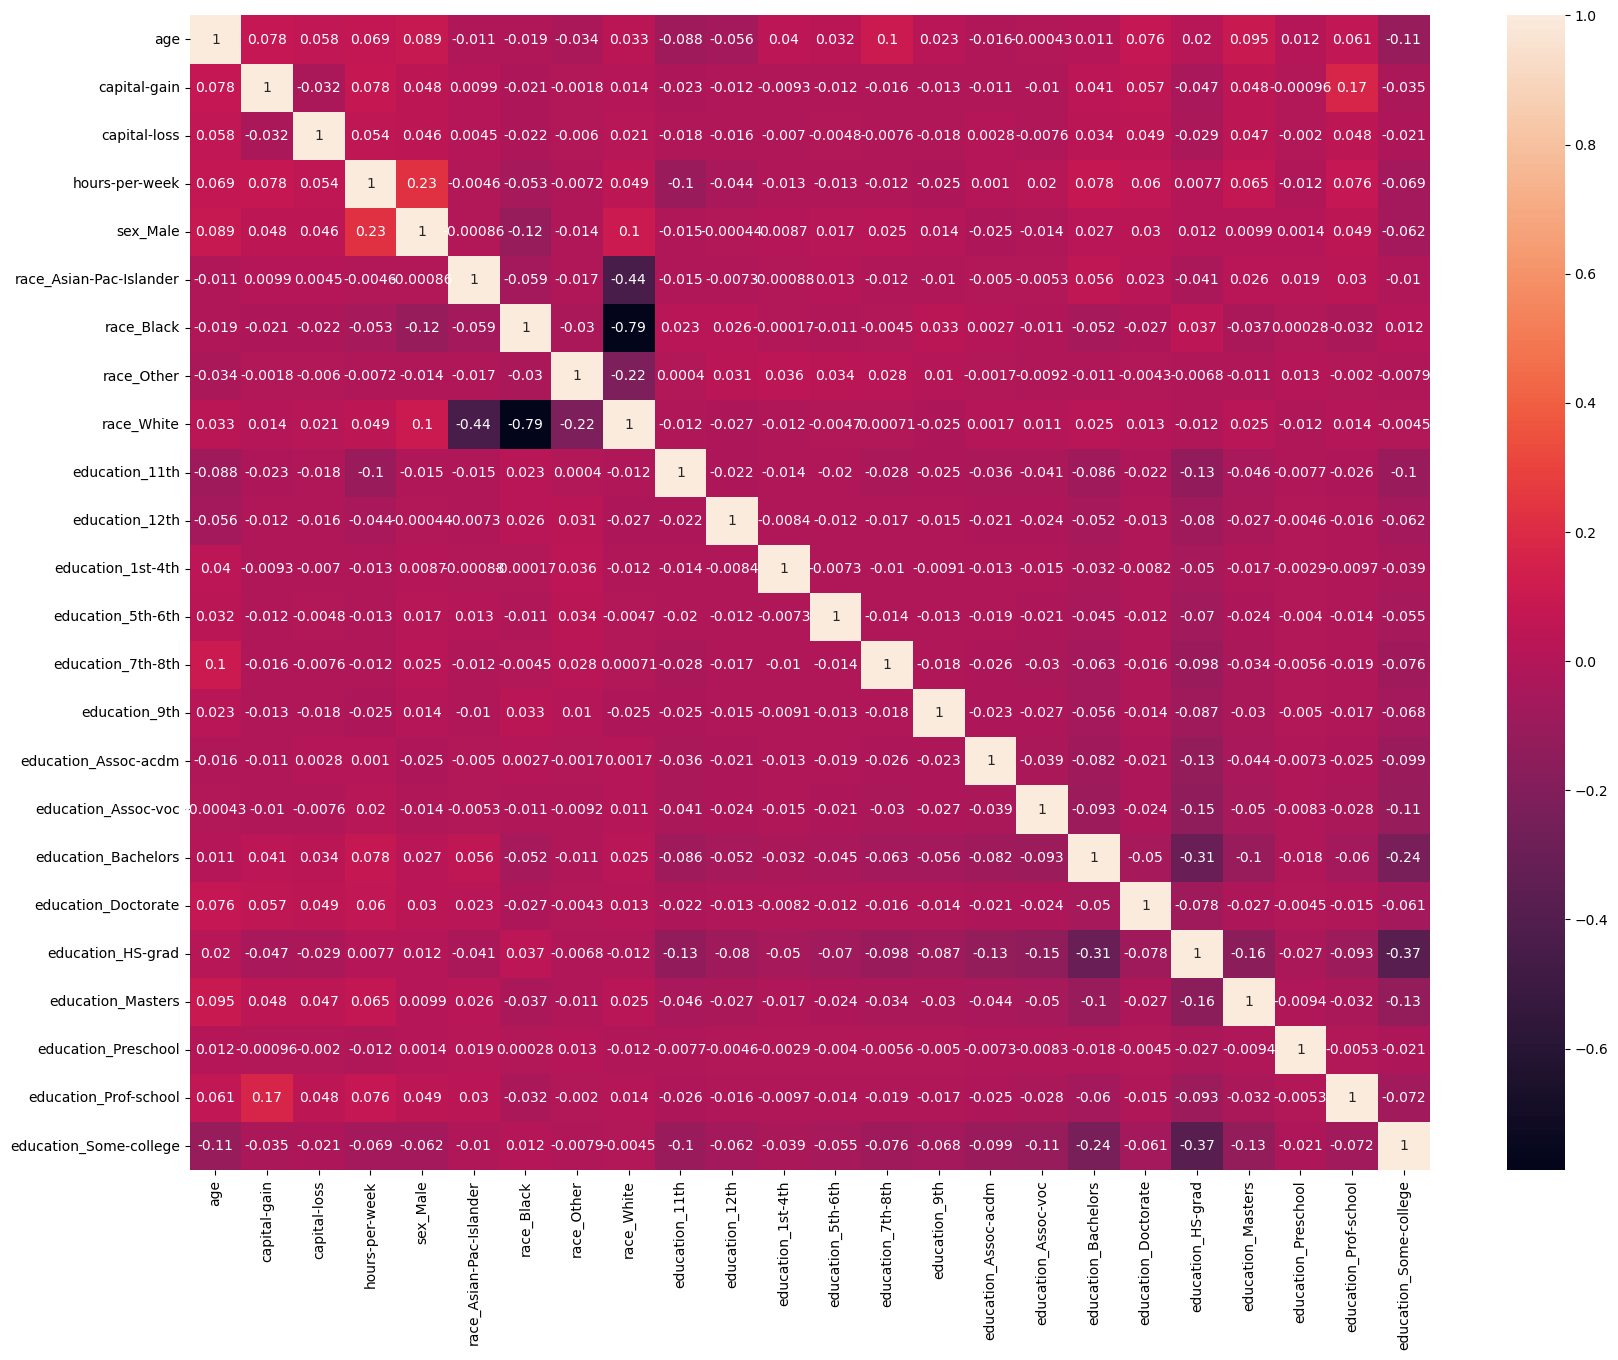

In [9]:
# Create a heatmap of X data to see feature correlation
plt.figure(figsize=(20,15))
sns.heatmap(X.corr(), annot=True)
plt.show()
plt.close()

In [10]:
# Scaling is not needed since the feature variables are in binaries.
# Output variable y, which is binary, 0 when income is <= 50K, 1 when income is >50K
y = np.where(df['income'] == '<=50K', 0, 1)

In [11]:
# Split data into training and testing set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
model = LogisticRegression(C=0.05, penalty='l1', solver='liblinear')

# Fit model using train set, and predict using test set
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Model parameters: Intercept
print("Model Parameter, Intercept:")
model.intercept_

Model Parameter, Intercept:


array([-5.62108952])

In [12]:
# Model parameter: coefficients
print("Model Parameter, Coefficients:")
model.coef_

Model Parameter, Coefficients:


array([[ 3.69095130e-02,  3.14927952e-04,  6.66677119e-04,
         3.22151075e-02,  1.03396465e+00,  0.00000000e+00,
        -3.37331283e-01,  0.00000000e+00,  9.72688995e-02,
        -5.72071276e-01,  0.00000000e+00,  0.00000000e+00,
        -3.98920031e-01, -8.95882875e-01, -5.00307824e-01,
         5.76249598e-01,  5.50919327e-01,  1.28826153e+00,
         1.80099203e+00,  0.00000000e+00,  1.60301808e+00,
         0.00000000e+00,  1.82744655e+00,  3.88580474e-01]])

In [13]:
# Evaluate the predictions of the model on the test set. Print the confusion matrix and accuracy score
print("Confusion Matrix on test set:")
confusion_matrix(y_test, y_pred)

Confusion Matrix on test set:


array([[4774,  252],
       [ 879,  608]])

In [14]:
# The following codes both produce the same result. So either method is fine.
print("Accuracy Score on test set:")
accuracy_score(y_test, y_pred)

Accuracy Score on test set:


0.8263473053892215

In [15]:
model.score(x_test, y_test)

0.8263473053892215

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>In general, education has the most effect on income.</li>
        <li>education_7th-8th has the strongest negative effect on income.</li>
        <li>education_Prof-school has the strongest positive effect on income.</li>
    </ul>
</div>

In [16]:
# Create a new DataFrame of the model coefficients and variable names; sort values based on coefficient
coef_df = pd.DataFrame(zip(x_train.columns, model.coef_[0]), columns=['var', 'coef']).sort_values('coef')
coef_df = coef_df[coef_df.coef.abs()>0].sort_values('coef')
coef_df

,var,coef
13,education_7th-8th,-0.895883
9,education_11th,-0.572071
14,education_9th,-0.500308
12,education_5th-6th,-0.398920
6,race_Black,-0.337331
1,capital-gain,0.000315
2,capital-loss,0.000667
3,hours-per-week,0.032215
0,age,0.036910
8,race_White,0.097269


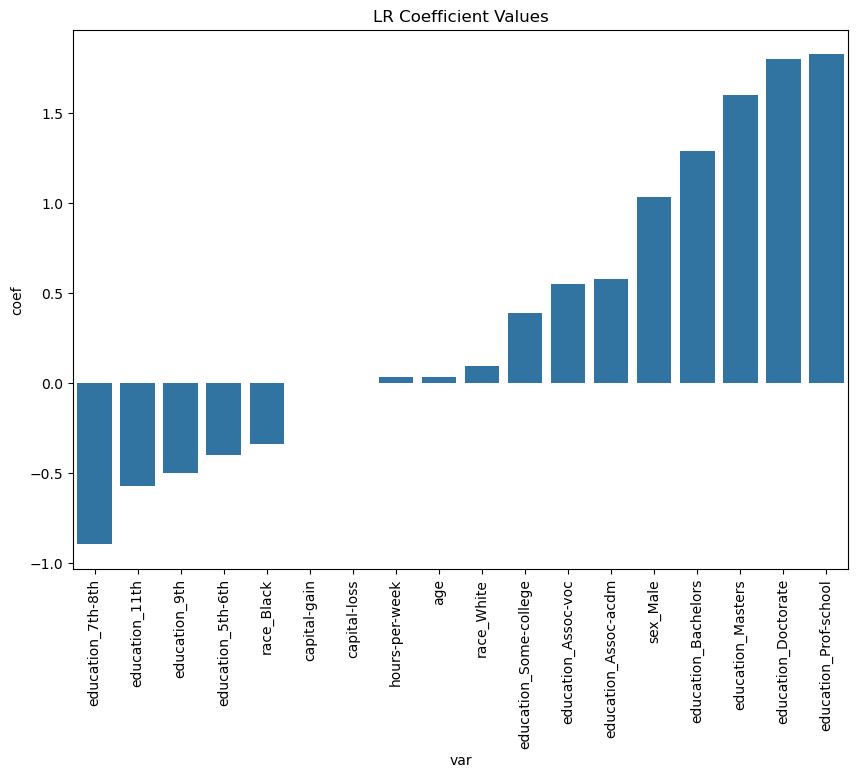

In [17]:
# Barplot of the coefficients sorted in ascending order
plt.figure(figsize=(10,7))
sns.barplot(x='var', y='coef', data=coef_df)
plt.xticks(rotation=90)
plt.title('LR Coefficient Values') 
plt.show()
plt.close()

<div style='background-color: #e6f7ff; padding: 10px;'>
    <ul>
        <li>The AUC score is 0.8, close to 1. The model has excellent ability to distinguish between the two classes. This shows strong model performance and good separability.</li>
    </ul>
</div>

In [18]:
# Plot ROC curve and print AUC value
y_pred_prob = model.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, y_pred_prob[:,1])
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8457240908138474


<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>The ROC curve for our model stays above the baseline, showing high true positive rate for various thresholds. This indicates the model is effective in distinguishing between classes.</li>
    </ul>
</div>

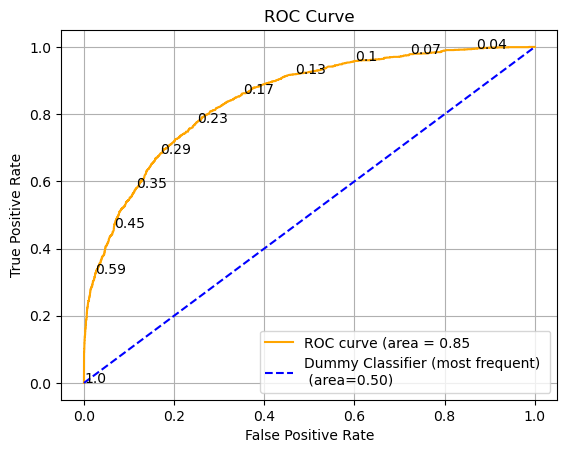

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[:, 1])
plt.figure()
plt.plot(fpr, tpr, color="orange", label='ROC curve (area = %0.2f' % roc_auc)

idx = list(range(len(thresholds)))[1::200]
for i in idx:
    plt.text(fpr[i], tpr[i], thresholds[i].round(2))

clf = DummyClassifier(strategy='most_frequent', random_state=0)
clf.fit(x_train, y_train)
roc_auc = roc_auc_score(y_test, clf.predict_proba(x_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(x_test)[:, 1])
plt.plot(fpr, tpr, color='blue', linestyle='--', label='Dummy Classifier (most frequent) \n (area=%0.2f)' % roc_auc)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.plot([0,1], [0,1], color='blue', linestyle='--')
plt.title('ROC Curve')
plt.grid()
plt.legend()
plt.show()
plt.close()